# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "hcfc142b"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[2.79 2.874 2.958 ... 3.7783333333333338 4.11 4.02] [2.79 2.874 2.958 ... 3.693333333333333 3.8566666666666665 4.02] [2.79 2.874 2.962857142857143 ... 3.8230188679245285 3.942452830188679 4.02] [2.79 2.909433962264151 3.028867924528302 ... 3.8649056603773584 3.9843396226415093 4.02] [2.79 2.874 2.914166666666667 ... 3.906792452830189 4.02622641509434 4.02] [2.79 2.874 2.958 ... 3.9486792452830195 4.06811320754717 4.02]] [[2.77 2.678888888888889 2.5877777777777777 ... 4.535 4.3175 4.1] [2.77 2.678888888888889 2.6906060606060604 ... 4.026666666666666 4.0633333333333335 4.1] [2.77 2.7303030303030305 2.888571428571429 ... 3.6991666666666663 4.178194444444444 4.1] [2.77 2.856060606060606 2.942121212121212 ... 4.256388888888888 4.3175 4.1] [2.77 2.678888888888889 2.6763636363636363 ... 4.534999999999999 4.3175 4.1] [2.77 2.678888888888889 2.5877777777777777 ... 4.535 4.3175 4.1]] [[3.08 3.1983333333333333 3.316666666666667 ... 4.7860000000000005 5.31 5.31] [3.08 3.1983333333333333 3.138181818181818 ... 5.042142857142856 5.31 5.31] [3.08 3.1090909090909093 3.1246666666666667 ... 5.042142857142856 5.31 5.31] [3.08 3.2705172413793107 3.461034482758621 ... 5.042142857142856 5.31 5.31] [3.08 3.1983333333333333 3.3527586206896554 ... 5.042142857142856 5.31 5.31] [3.08 3.1983333333333337 3.3166666666666664 ... 5.042142857142856 5.31 5.31]] ... [[20.424999999999997 20.41333333333333 20.401666666666667 ... 21.352083333333333 21.3775 21.325000000000003] [20.424999999999997 20.41333333333333 20.384999999999998 ... 21.68 21.5025 21.325000000000003] [20.424999999999997 20.404999999999998 20.46035714285714 ... 21.31 21.324166666666667 21.325000000000003] [20.424999999999997 20.507619047619045 20.590238095238092 ... 21.290925925925926 21.337500000000002 21.325000000000003] [20.424999999999997 20.41333333333333 20.448809523809523 ... 21.271851851851853 21.350833333333334 21.325000000000003] [20.424999999999997 20.413333333333334 20.401666666666664 ... 21.252777777777776 21.36416666666667 21.325000000000003]] [[20.32 20.310833333333335 20.301666666666666 ... 21.2875 21.3325 21.295] [20.32 20.31083333333333 20.37273684210526 ... 21.986666666666668 21.640833333333333 21.295] [20.32 20.34636842105263 20.47934210526316 ... 21.22 21.265833333333333 21.295] [20.32 20.404404761904765 20.488809523809522 ... 21.21064814814815 21.282500000000002 21.295] [20.32 20.310833333333335 20.348452380952384 ... 21.201296296296295 21.299166666666665 21.295] [20.32 20.310833333333335 20.301666666666666 ... 21.19194444444444 21.31583333333333 21.295]] [[20.33 20.304166666666667 20.278333333333336 ... 21.233333333333334 21.23 21.246] [20.33 20.304166666666667 20.36030701754386 ... 21.27 21.258 21.246] [20.33 20.34515350877193 20.48326754385965 ... 21.23 21.23711111111111 21.246] [20.33 20.41202380952381 20.49404761904762 ... 21.1937962962963 21.235333333333333 21.246] [20.33 20.304166666666664 20.332261904761904 ... 21.157592592592593 21.233555555555554 21.246] [20.33 20.304166666666667 20.278333333333332 ... 21.121388888888887 21.23177777777778 21.246]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[2.79 2.874 2.958 ... 3.7783333333333338 4.11 4.02] [2.79 2.874 2.958 ... 3.693333333333333 3.8566666666666665 4.02] [2.79 2.874 2.962857142857143 ... 3.8230188679245285 3.942452830188679 4.02] [2.79 2.909433962264151 3.028867924528302 ... 3.8649056603773584 3.9843396226415093 4.02] [2.79 2.874 2.914166666666667 ... 3.906792452830189 4.02622641509434 4.02] [2.79 2.874 2.958 ... 3.9486792452830195 4.06811320754717 4.02]] [[2.77 2.678888888888889 2.5877777777777777 ... 4.535 4.3175 4.1] [2.77 2.678888888888889 2.6906060606060604 ... 4.026666666666666 4.0633333333333335 4.1] [2.77 2.7303030303030305 2.888571428571429 ... 3.6991666666666663 4.178194444444444 4.1] [2.77 2.856060606060606 2.942121212121212 ... 4.256388888888888 4.3175 4.1] [2.77 2.678888888888889 2.6763636363636363 ... 4.534999999999999 4.3175 4.1] [2.77 2.678888888888889 2.5877777777777777 ... 4.535 4.3175 4.1]] [[3.08 3.1983333333333333 3.316666666666667 ... 4.7860000000000005 5.31 5.31] [3.08 3.1983333333333333 3.138181818181818 ... 5.042142857142856 5.31 5.31] [3.08 3.1090909090909093 3.1246666666666667 ... 5.042142857142856 5.31 5.31] [3.08 3.2705172413793107 3.461034482758621 ... 5.042142857142856 5.31 5.31] [3.08 3.1983333333333333 3.3527586206896554 ... 5.042142857142856 5.31 5.31] [3.08 3.1983333333333337 3.3166666666666664 ... 5.042142857142856 5.31 5.31]] ... [[20.424999999999997 20.41333333333333 20.401666666666667 ... 21.352083333333333 21.3775 21.325000000000003] [20.424999999999997 20.41333333333333 20.384999999999998 ... 21.68 21.5025 21.325000000000003] [20.424999999999997 20.404999999999998 20.46035714285714 ... 21.31 21.324166666666667 21.325000000000003] [20.424999999999997 20.507619047619045 20.590238095238092 ... 21.290925925925926 21.337500000000002 21.325000000000003] [20.424999999999997 20.41333333333333 20.448809523809523 ... 21.271851851851853 21.350833333333334 21.325000000000003] [20.424999999999997 20.413333333333334 20.401666666666664 ... 21.252777777777776 21.36416666666667 21.325000000000003]] [[20.32 20.310833333333335 20.301666666666666 ... 21.2875 21.3325 21.295] [20.32 20.31083333333333 20.37273684210526 ... 21.986666666666668 21.640833333333333 21.295] [20.32 20.34636842105263 20.47934210526316 ... 21.22 21.265833333333333 21.295] [20.32 20.404404761904765 20.488809523809522 ... 21.21064814814815 21.282500000000002 21.295] [20.32 20.310833333333335 20.348452380952384 ... 21.201296296296295 21.299166666666665 21.295] [20.32 20.310833333333335 20.301666666666666 ... 21.19194444444444 21.31583333333333 21.295]] [[20.33 20.304166666666667 20.278333333333336 ... 21.233333333333334 21.23 21.246] [20.33 20.304166666666667 20.36030701754386 ... 21.27 21.258 21.246] [20.33 20.34515350877193 20.48326754385965 ... 21.23 21.23711111111111 21.246] [20.33 20.41202380952381 20.49404761904762 ... 21.1937962962963 21.235333333333333 21.246] [20.33 20.304166666666664 20.332261904761904 ... 21.157592592592593 21.233555555555554 21.246] [20.33 20.304166666666667 20.278333333333332 ... 21.121388888888887 21.23177777777778 21.246]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'hcfc142b' (lon: 6, lat: 12, year: 26, month: 12)> Size: 180kB
<Quantity([[[[ 8.55        8.255       8.355      ...  8.98        9.04
     9.09      ]
   [ 8.99        9.085       9.4        ...  9.91       10.09
    10.015     ]
   [10.165      10.39       10.49       ... 10.99       10.99
    11.105     ]
   ...
   [21.13       21.0725     21.11       ... 21.08666667 21.02666667
    21.00333333]
   [20.9475     20.89       20.95333333 ... 20.865      20.79666667
    20.8075    ]
   [20.705      20.77       20.73333333 ... 20.565      20.62333333
    20.525     ]]

  [[ 8.55        8.255       8.401875   ...  9.26998333  9.3352
     9.3638    ]
   [ 9.1672      9.32128333  9.29495    ... 10.43296667 10.47523333
    10.2155    ]
   [10.5974     10.51783333 10.60195    ... 11.150575   11.08246667
    11.1108    ]
...
   [22.39933333 22.46133333 22.4405     ... 22.21866667 22.30583333
    22.28616667]
   [22.25466667 22.09566667 22.14       ... 21.94944444 21.9415
    21.9205    ]
   [21.808      21.79416667 21.83711111 ... 21.79466667 21.77
    21.814     ]]

  [[10.82       10.825      10.7        ... 11.55333333 11.86333333
    12.03      ]
   [12.23       11.98       12.11666667 ... 12.62       12.82
    12.8975    ]
   [12.95333333 13.17333333 13.14       ... 13.625      13.81
    13.87      ]
   ...
   [22.57316667 22.5655     22.4985     ... 22.4195     22.40375
    22.399     ]
   [22.36525    22.27725    22.254      ... 21.98225    22.00116667
    21.8555    ]
   [21.895      21.926      21.99866667 ... 21.78516667 21.828
    21.8685    ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 208B 1998 1999 2000 2001 2002 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[8.55 8.254999999999999 8.355 ... 20.565 20.623333333333335 20.525] [8.55 8.254999999999999 8.401875 ... 20.60985 20.57051666666667 20.550483333333332] [8.342500000000001 8.259166666666665 8.454374999999999 ... 20.69925 20.669249999999998 20.637416666666667] ... [10.357777777777777 10.550833333333333 10.322777777777777 ... 21.69125 21.646500000000003 21.68625] [10.74 10.825 10.57 ... 21.656 21.5825 21.655] [10.82 10.825 10.7 ... 21.67425 21.707 21.75675]] [[8.55 8.254999999999999 8.355 ... 20.565 20.623333333333335 20.525] [8.55 8.254999999999999 8.399999999999999 ... 20.595 20.52 20.53] [9.370000000000001 8.59952380952381 8.642857142857142 ... 20.808214285714286 20.689642857142857 20.702440476190475] ... [10.82 11.0 10.3 ... 21.975 21.83 21.68] [10.82 10.825 10.5 ... 21.769166666666667 21.708 21.6625] [10.82 10.825 10.7 ... 21.563333333333333 21.586 21.645]] [[8.55 8.254999999999999 8.355 ... 20.565 20.623333333333335 20.525] [8.55 8.254999999999999 8.498928571428571 ... 20.65229411764706 20.647127450980392 20.628090909090908] [8.85625 8.429345238095237 8.741785714285715 ... 20.796882352941175 20.798049019607845 20.829272727272727] ... [10.14875 10.88862745098039 10.1521875 ... 21.808999999999997 21.8545 21.62] [10.512777777777778 10.825 10.442083333333333 ... 21.66 21.595 21.6] [10.82 10.825 10.7 ... 21.78516666666667 21.828 21.868499999999997]] [[8.55 8.254999999999999 8.355 ... 20.565 20.623333333333335 20.525] [8.55 8.254999999999999 8.527613636363636 ... 20.7533125 20.82135416666667 20.7226875] [8.3425 8.259166666666665 8.700227272727272 ... 20.941625000000002 21.019375 20.920375] ... [10.205555555555556 10.777254901960784 10.184166666666666 ... 22.137 22.22 22.172] [10.569583333333334 10.825 10.474062499999999 ... 22.072000000000003 22.145 22.131999999999998] [10.82 10.825 10.7 ... 22.007 22.07 22.092]] [[8.55 8.254999999999999 8.355 ... 20.565 20.623333333333335 20.525] [8.55 8.254999999999999 8.405625 ... 20.63955 20.67155 20.59145] [8.342500000000001 8.259166666666667 8.518181818181818 ... 20.778406250000003 20.819927083333333 20.733760416666666] ... [10.262361111111112 10.665882352941177 10.216145833333334 ... 21.988416666666666 22.02883333333333 22.01008333333333] [10.626388888888888 10.825 10.506041666666667 ... 21.933333333333334 21.957500000000003 21.973] [10.82 10.825 10.7 ... 21.896083333333333 21.948999999999998 21.980249999999998]] [[8.55 8.254999999999999 8.355 ... 20.565 20.623333333333335 20.525] [8.55 8.254999999999999 8.40375 ... 20.6247 20.621033333333333 20.570966666666667] [8.3425 8.259166666666665 8.456249999999999 ... 20.7141 20.71976666666667 20.6579] ... [10.319166666666666 10.554509803921567 10.248125 ... 21.839833333333335 21.837666666666667 21.848166666666668] [10.683194444444444 10.825 10.538020833333334 ... 21.794666666666668 21.77 21.814] [10.82 10.825 10.7 ... 21.78516666666667 21.828 21.868499999999997]]]
Units,ppt


### Longitudinal-mean

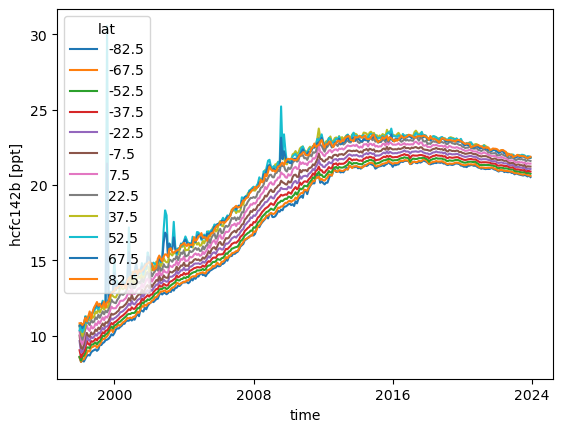

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

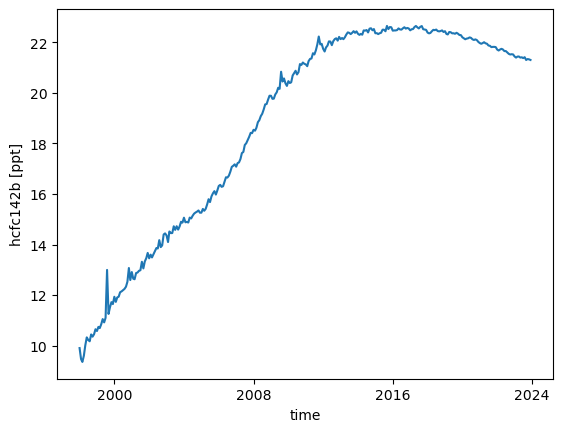

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

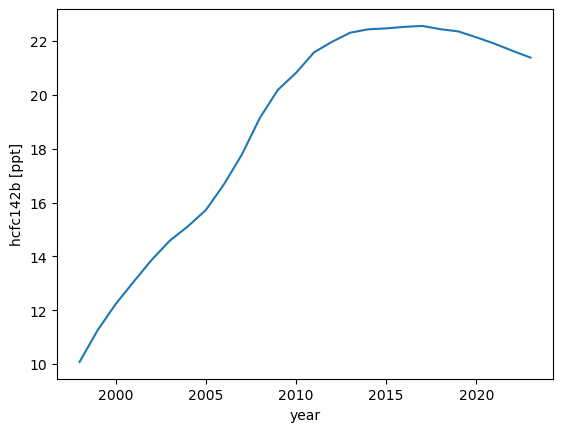

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 4kB
Dimensions:               (lat: 12, eof: 12, year: 26)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 208B 1998 1999 2000 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.4413 0.18 ... -0.05329
    principal-components  (year, eof) float64 2kB [] -3.141 ... 1.641e-15

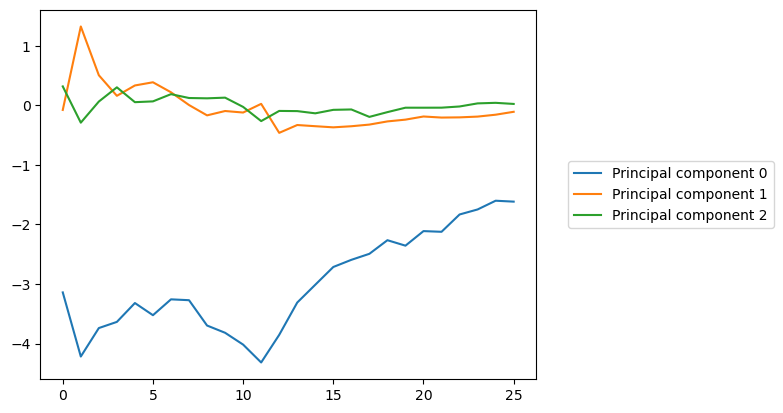

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

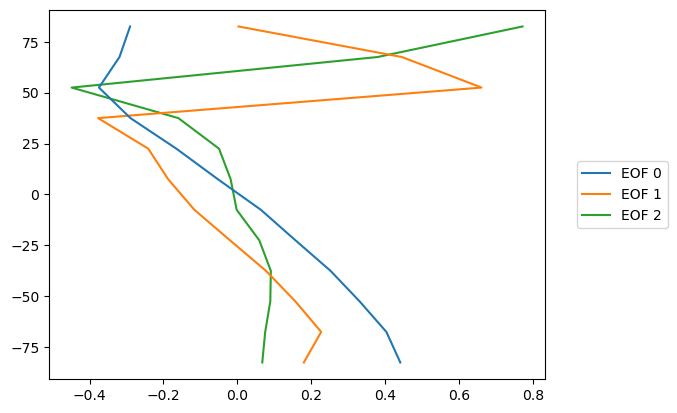

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

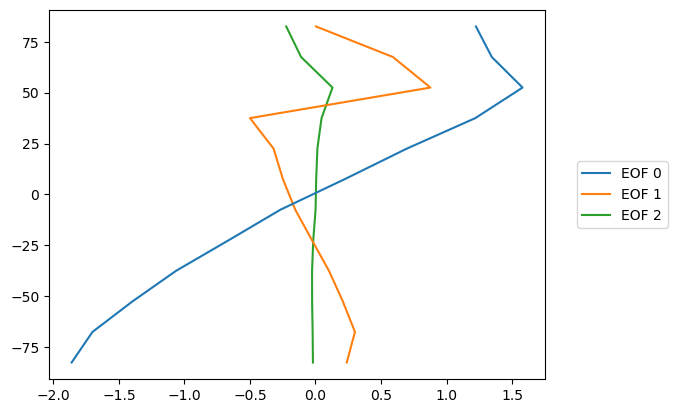

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.44129497543854085] [0.4036194762359377] [0.33117824758148057] [0.2523687206465905] [0.15736657300873988] [0.06359730985165149] [-0.05269860067407813] [-0.16510080039538796] [-0.2892195373638689] [-0.37469982568171395] [-0.31903835121915913] [-0.2903505081641583]]
Units,ppt
Magnitude,[[-3.1408455480599002] [-4.21801191070893] [-3.739669822392628] [-3.6361267744762773] [-3.3193030780235167] [-3.523640337389741] [-3.257330803886639] [-3.271668508619262] [-3.697186275503038] [-3.8189461282896353] [-4.017716275207341] [-4.317864238937876] [-3.853930903765765] [-3.3109790716668828] [-3.011905484558647] [-2.713656311121547] [-2.5935882824053884] [-2.4923998108818597] [-2.2638815272585697] [-2.3557166298270547] [-2.111004076755414] [-2.122611919462133] [-1.8318237108295967] [-1.7473047687380467] [-1.6006378751478665] [-1.6159415970523245]]
Units,dimensionless


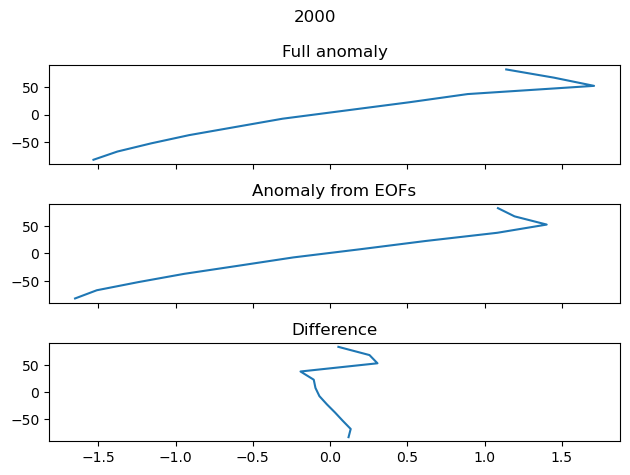

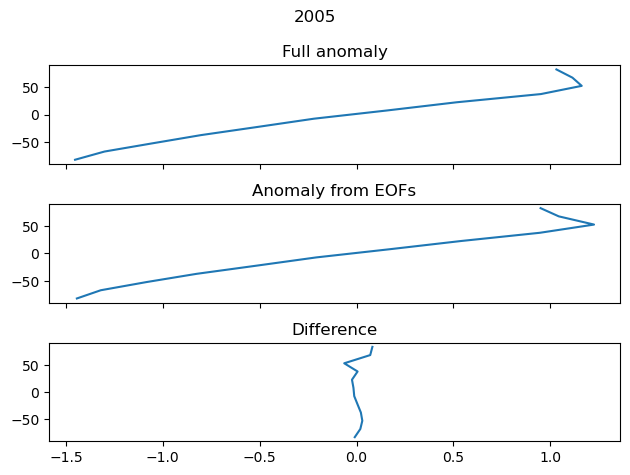

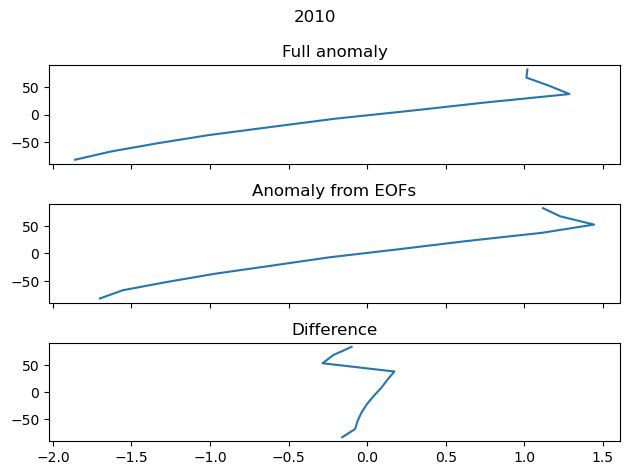

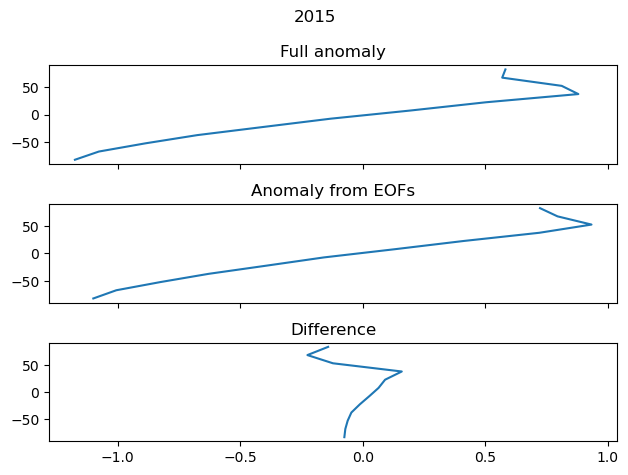

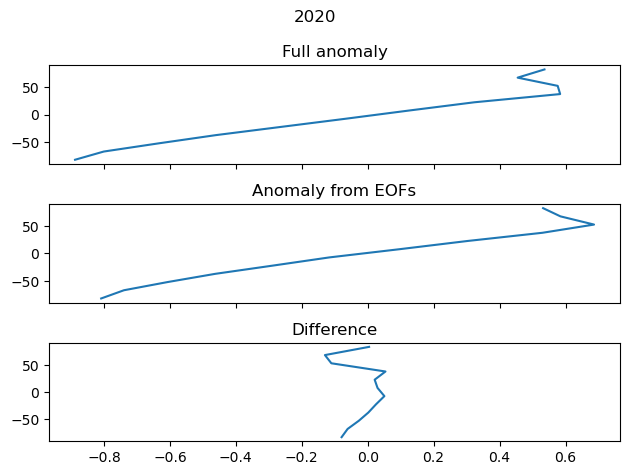

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312/312 [00:00<00:00, 14454.49it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312/312 [00:00<00:00, 18965.27it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312/312 [00:00<00:00, 19759.06it/s]

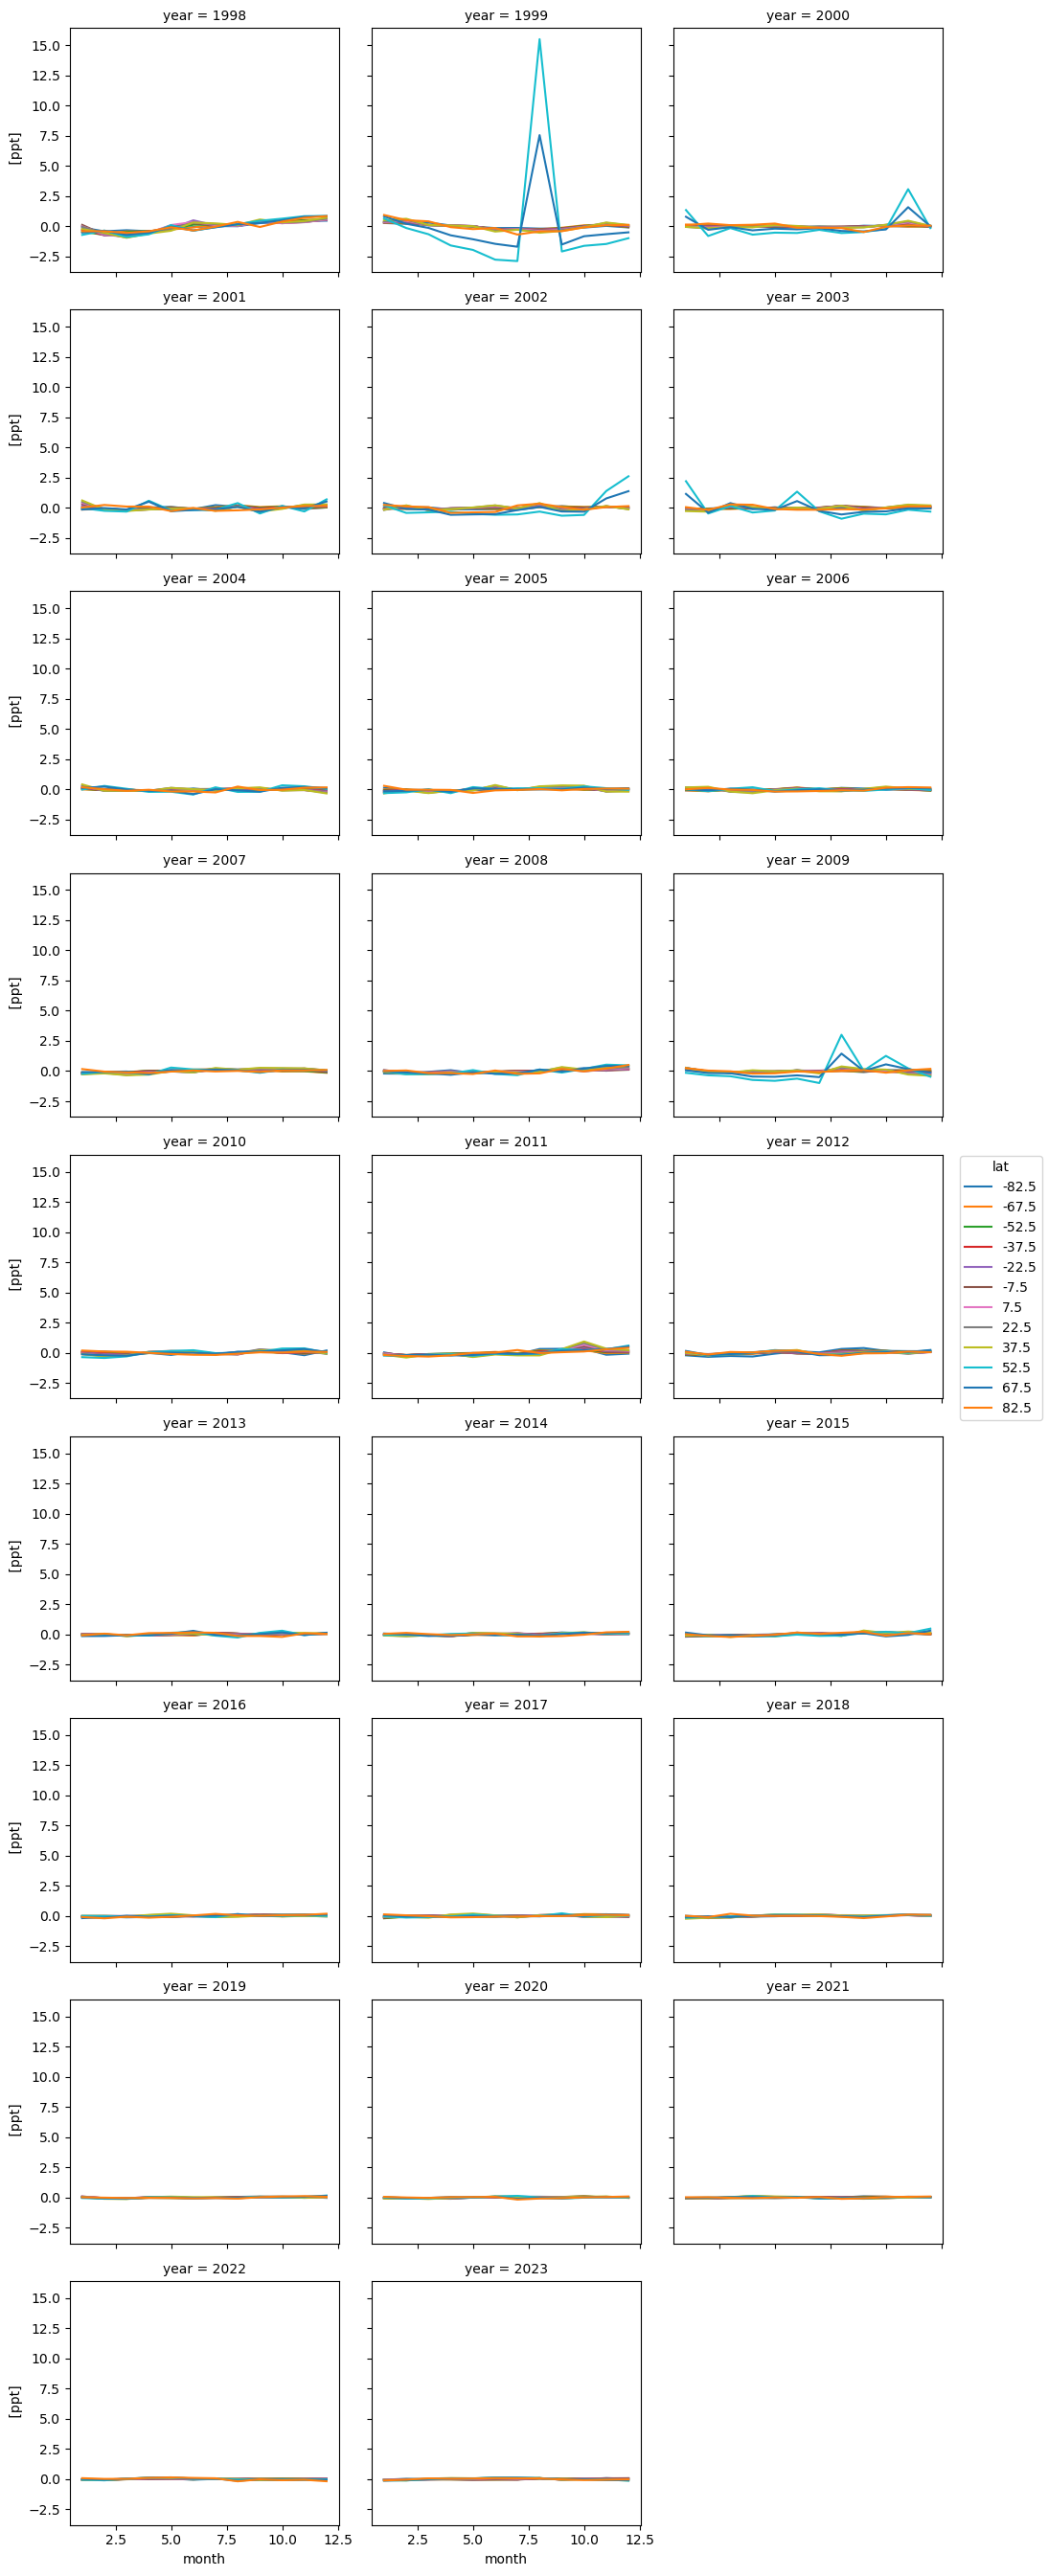

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

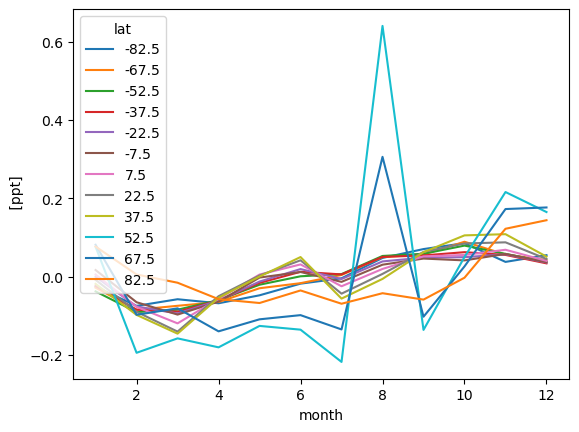

In [22]:
seasonality.plot.line(hue="lat")

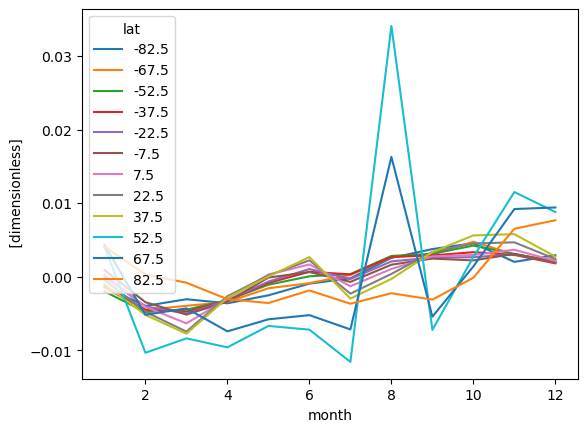

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[10.078944244895537 11.254963462507844 12.227093985430882 13.060291381714464 13.872056638531815 14.582202597397192 15.11317254715455 15.720275351772662 16.671062523192575 17.784633812611784 19.148323528175226 20.19113272447586 20.816915614920504 21.581100346119673 21.972976478273903 22.308980093307568 22.436163814824408 22.470939080592867 22.52645816836184 22.561721827916227 22.441112716658683 22.357960984658845 22.137387454642862 21.90374152177011 21.6365360878281 21.385237989655902]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.44129497543854085] [0.4036194762359377] [0.33117824758148057] [0.2523687206465905] [0.15736657300873988] [0.06359730985165149] [-0.05269860067407813] [-0.16510080039538796] [-0.2892195373638689] [-0.37469982568171395] [-0.31903835121915913] [-0.2903505081641583]]
Units,ppt
Magnitude,[[-3.1408455480599002] [-4.21801191070893] [-3.739669822392628] [-3.6361267744762773] [-3.3193030780235167] [-3.523640337389741] [-3.257330803886639] [-3.271668508619262] [-3.697186275503038] [-3.8189461282896353] [-4.017716275207341] [-4.317864238937876] [-3.853930903765765] [-3.3109790716668828] [-3.011905484558647] [-2.713656311121547] [-2.5935882824053884] [-2.4923998108818597] [-2.2638815272585697] [-2.3557166298270547] [-2.111004076755414] [-2.122611919462133] [-1.8318237108295967] [-1.7473047687380467] [-1.6006378751478665] [-1.6159415970523245]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-0.0013773417377949996 -0.003976948717416238 -0.0030727578446687782 -0.0036201313834163663 -0.0025385715859465034 -0.0009533680153284871 -0.00022543203081676485 0.0025437418982757554 0.00374923377071997 0.004548541642825278 0.002005235410818057 0.0029178070151999703] [-0.0015068798006237156 -0.004504849481221879 -0.0039646417473965054 -0.003451298541063982 -0.001578826661441866 -0.0008880067520839592 0.00022742438725110645 0.002668774568288978 0.0030020683135768937 0.004744641242972429 0.003010632126936376 0.0022409715659743685] [-0.002006776624881476 -0.004819458753163379 -0.004494397684564278 -0.003198677483123395 -0.001098879724462337 4.7539696022872204e-05 0.00034363545058289235 0.002812230942839282 0.0031093912172627768 0.004221811709213048 0.0030962119598218693 0.0019873784094054546] [-0.0012553714973200481 -0.004498162560728562 -0.004765452253809267 -0.0032428266373102856 -0.0008531295896350107 0.0006575387398832893 0.00030271843307770016 0.002683397590479217 0.0028840632026014127 0.003326462516969204 0.002954294171301949 0.0018064770657890217] [-8.422814566797777e-06 -0.00404960486864373 -0.005010256812322053 -0.003238866716134999 -0.0006696258541679059 0.001028617517575705 -0.0003221794412147347 0.002070316931219937 0.0025881323890659027 0.002643756441047492 0.003041122828735892 0.0019270190311624791] [0.0008998266728943463 -0.003479135428523335 -0.005160527354293186 -0.003396729919850383 -0.00012641979274910167 0.0006305998909313918 -0.0007112330552678808 0.001623224441243405 0.0024568645047637274 0.002208584282690256 0.003090915571806585 0.0019640382892899036] [0.00028602214886217723 -0.0041072994330966835 -0.006354366454586755 -0.0030116701717283045 0.00028275072745430937 0.0016616185980502184 -0.0013086097271943356 0.0010473377320537785 0.0027577028650010273 0.0029475438093919345 0.003654529398306445 0.002144442995093681] [-0.000437749644212974 -0.004787415071821017 -0.007473794768217134 -0.0026636758331829145 0.00014944796586270596 0.002221055340375963 -0.0023143650345722744 0.00037022392948576405 0.003357797744896738 0.004509486397092136 0.0046652667960161796 0.002403720524153708] [-0.0009853581181295107 -0.0052031895588586525 -0.007754345181283442 -0.002871327388761466 1.190398613488677e-05 0.0026623152365773083 -0.002986675274874719 -0.0003094795598920094 0.0033295332006329646 0.005610321613752425 0.005774301920951307 0.002721997866656391] [0.004063032150820173 -0.010355068603704515 -0.008394900806551872 -0.009615334110334788 -0.006700561469030187 -0.007210438489050821 -0.01159681653571586 0.0340917890470822 -0.007243904971639266 0.0026733374752465314 0.011503631136775815 0.008785234916719724] [0.00433046704835355 -0.005188913015247116 -0.0043109442120043764 -0.007439540487828157 -0.005803911197367283 -0.005234799813539272 -0.007179257428332892 0.016289725936143903 -0.005449733985370721 0.001388851823033053 0.009191893945523937 0.00940615940894183] [0.004087058800458086 0.0002926709264565767 -0.0008263808415370914 -0.0030624947919047213 -0.0035864240241316493 -0.0018788334679772012 -0.003684801573667008 -0.0022528533133725852 -0.0031234124123961757 -0.00014568285427215286 0.006509466314416655 0.0076716869039509215]]
Units,dimensionless
